In [23]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
from sklearn.metrics import precision_score

In [24]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True)
mnist_test = datasets.MNIST(root="./data", train=False, download=True)

X_train = mnist_train.data.float() / 255.0 # normalize between 0 and 1
y_train = mnist_train.targets.long()
X_test = mnist_test.data.float() / 255.0
y_test = mnist_test.targets.long()

In [25]:
# Convert into pytorch tensors
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)

In [26]:
class MNIST_FNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 64) 
        self.fc2 = nn.Linear(64, 32) 
        self.fc3 = nn.Linear(32, 32)  
        self.fc4 = nn.Linear(32, 10)    

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten the image, keep the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x
    
def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    batch_acc = []
    batch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        batch_acc.append(batch_acc_item)
        batch_loss.append(loss.item())
        
    return np.mean(batch_acc), np.mean(batch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

In [27]:
# Check the initial weights of the first layer
temp_net = MNIST_FNN()
print(temp_net.fc1.weight.data) # initialized to different random values every time we instantiate the model

tensor([[ 0.0130,  0.0327, -0.0318,  ..., -0.0083,  0.0330,  0.0325],
        [ 0.0147,  0.0277, -0.0107,  ...,  0.0166, -0.0241,  0.0082],
        [ 0.0097, -0.0208, -0.0153,  ...,  0.0142,  0.0255,  0.0086],
        ...,
        [ 0.0077,  0.0078, -0.0107,  ...,  0.0254, -0.0229,  0.0256],
        [-0.0150, -0.0161, -0.0203,  ..., -0.0097, -0.0313, -0.0264],
        [-0.0350,  0.0140, -0.0157,  ..., -0.0056, -0.0089,  0.0247]])


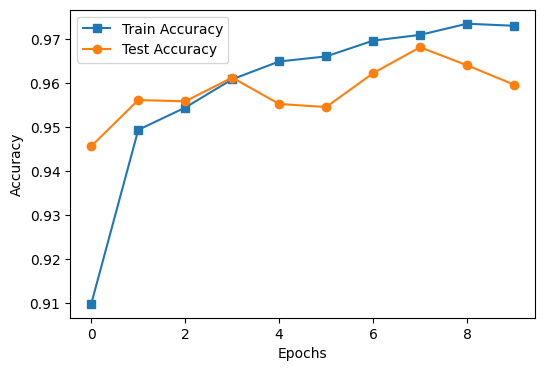

In [28]:
learning_rate = 0.01
epochs = 10

model = MNIST_FNN()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs)

plt.figure(figsize=(6, 4))
plt.plot(train_acc, "s-", label="Train Accuracy")
plt.plot(test_acc, "o-", label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

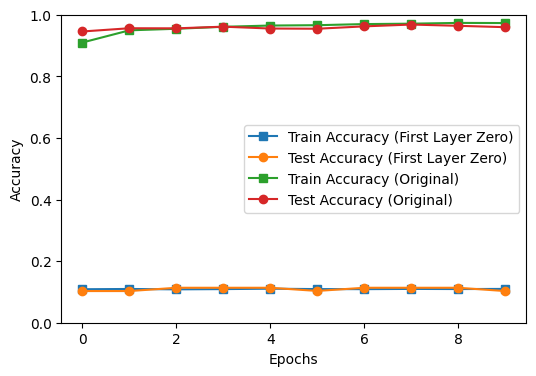

In [29]:
# set all the weights from layer 1 to zero and see what happens
model_first_zero = MNIST_FNN()
with torch.no_grad():
    model_first_zero.fc1.weight.zero_()
    model_first_zero.fc1.bias.zero_()
optimizer = torch.optim.Adam(model_first_zero.parameters(), lr=learning_rate)

train_acc_first_zero, test_acc_first_zero, losses = train_model(model_first_zero, train_dl, test_dl, optimizer, loss_fn, epochs)

plt.figure(figsize=(6, 4))
plt.plot(train_acc_first_zero, "s-", label="Train Accuracy (First Layer Zero)")
plt.plot(test_acc_first_zero, "o-", label="Test Accuracy (First Layer Zero)")
plt.plot(train_acc, "s-", label="Train Accuracy (Original)")
plt.plot(test_acc, "o-", label="Test Accuracy (Original)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()

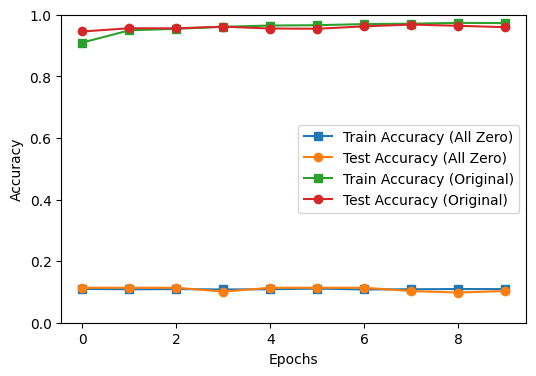

In [30]:
# now turn all the weights to zero and see what happens
model_all_zero = MNIST_FNN()
with torch.no_grad():
    for param in model_all_zero.parameters():
        param.zero_()

optimizer = torch.optim.Adam(model_all_zero.parameters(), lr=learning_rate)
train_acc_all_zero, test_acc_all_zero, losses = train_model(model_all_zero, train_dl, test_dl, optimizer, loss_fn, epochs)

plt.figure(figsize=(6, 4))
plt.plot(train_acc_all_zero, "s-", label="Train Accuracy (All Zero)")
plt.plot(test_acc_all_zero, "o-", label="Test Accuracy (All Zero)")
plt.plot(train_acc, "s-", label="Train Accuracy (Original)")
plt.plot(test_acc, "o-", label="Test Accuracy (Original)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [60]:
def init_weights(init_type='kaiming', distribution='normal'):
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            if init_type == 'kaiming' and distribution == 'normal':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif init_type == 'kaiming' and distribution == 'uniform':
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu') # default for pytorch
            elif init_type == 'xavier' and distribution == 'normal':
                nn.init.xavier_normal_(m.weight)
            elif init_type == 'xavier' and distribution == 'uniform':
                nn.init.xavier_uniform_(m.weight)
            
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return _init

model = MNIST_FNN()
#model.apply(init_weights(init_type='kaiming', distribution='uniform')) # this is the one applied by default
model.apply(init_weights(init_type='xavier', distribution='normal'))

MNIST_FNN(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=10, bias=True)
)

Mean: -0.0001, Std: 0.0483
Xavier initialization --> mean: 0, std: 0.0486


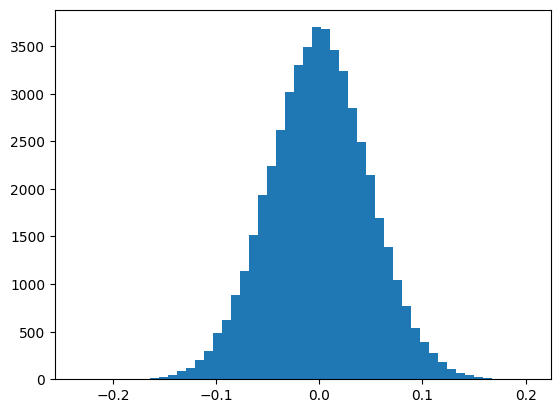

In [61]:
# plot the weights distribution in the one layer
# we can test this with fc1, fc2, fc3, fc4 and see how the distribution changes with the layer depth
# fc1 will look more like a normal distribution, while fc4 will look more like a uniform distribution, 
# because of the different number of input and output features
# the more weights the more normal the distribution will look, the less weights the more uniform it will look
weights = model.fc1.weight.data.cpu().numpy().flatten()
plt.hist(weights, bins=50)

# print the mean and the standard deviation of the weights
print(f"Mean: {weights.mean():.4f}, Std: {weights.std():.4f}")

# print xavier initialization formula for the standard deviation of the normal distribution
fan_in, fan_out = model.fc1.weight.data.shape
std = np.sqrt(2.0 / (fan_in + fan_out))
print(f"Xavier initialization --> mean: 0, std: {std:.4f}")